# 원자료 → 전처리 → Figure 1 · 중복 예시 · 매칭 표본 100개

**모든 셀을 순서대로 실행하세요.** 입력은 `data/herbal/`의 CSV 5개와 `data/recipe1m/`의 파일 2개입니다. 기존 `work/`나 `figures/`의 결과를 읽지 않고, 빈 작업 폴더에서 새로 계산합니다. 아래 출력은 실행 결과이며 집계 수치를 코드에 고정하지 않았습니다.

전처리와 평가 구현은 [run.py](https://github.com/inseong101/HerbalFormulaCompletion/blob/main/run.py)에 있습니다. 전처리, Figure 1, 중복 예시, 매칭 표본 100개, 추천 예시와 전체 추천 성능 평가를 재현합니다. 구조 분석과 학습곡선 분석은 포함하지 않습니다.


## 1. 코드와 원자료 준비
Colab에서 Git LFS를 설치한 뒤 코드를 복제하고, 원자료를 HTTPS로 내려받아 SHA-256을 검증합니다. 아래 설치 명령은 Colab/Linux용입니다.


In [1]:
from pathlib import Path
import csv, hashlib, importlib.util, json, os, shutil, subprocess, sys, tempfile
from collections import Counter
from urllib.request import urlopen
from IPython.display import Image, display

if shutil.which("apt-get"):
    !apt-get install -y git-lfs

IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "matplotlib>=3.9,<4", "tqdm>=4.66,<5"], check=True)
    repo = Path(tempfile.mkdtemp(prefix="hfc-source-")) / "repository"
    # Disable LFS filters: clone code and pointers without configuring Git globally.
    subprocess.run(["git", "-c", "filter.lfs.required=false", "-c", "filter.lfs.smudge=", "-c", "filter.lfs.process=", "clone", "https://github.com/inseong101/HerbalFormulaCompletion.git", str(repo)], env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"}, check=True)
    commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=repo, text=True).strip()
    # Fetch the actual LFS objects over HTTPS and verify their checksums.
    for name, expected in [
        ("det_ingrs.json", "e1399c338b004f83f3dd9d85a8479dd04f120666e35f4d67c4b6947fae07aa50"),
        ("recipe1M_layers.tar.gz", "e180260dcd438be96e63c1c68b5f09a6415d1d1c51b1f2c2bc0b08079cb5d6c3"),
    ]:
        destination = repo / "data/recipe1m" / name
        temporary = destination.with_name(name + ".download")
        url = f"https://media.githubusercontent.com/media/inseong101/HerbalFormulaCompletion/{commit}/data/recipe1m/{name}"
        print("Downloading:", name, flush=True)
        with urlopen(url, timeout=120) as response, temporary.open("wb") as handle:
            shutil.copyfileobj(response, handle, length=1024 * 1024)
        with temporary.open("rb") as handle:
            actual = hashlib.file_digest(handle, "sha256").hexdigest()
        if actual != expected:
            temporary.unlink()
            raise ValueError(f"Source checksum mismatch: {name}. Download rejected.")
        temporary.replace(destination)
        print("Verified:", name, destination.stat().st_size, "bytes", flush=True)
else:
    repo = Path.cwd()
    assert (repo / "run.py").is_file(), "Run this notebook in the repository directory."
print("Code commit:", subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=repo, text=True).strip())
import matplotlib
print("Python:", sys.version.split()[0], "Matplotlib:", matplotlib.__version__)


Code commit: fbc081f431f3ee8d3c4e9c465f2c8c408f4702d9
Python: 3.13.2 Matplotlib: 3.11.2


## 2. 입력 파일 확인 및 빈 작업 폴더 생성
파일 크기와 SHA-256을 기록합니다. 새 작업 폴더에는 `run.py`와 원자료 연결만 둡니다. 이전 분석표나 그림은 존재하지 않는 상태에서 시작합니다.


In [2]:
inputs = sorted((repo / "data/herbal").glob("*.csv")) + [repo / "data/recipe1m/det_ingrs.json", repo / "data/recipe1m/recipe1M_layers.tar.gz"]
assert len(inputs) == 7
manifest = []
for path in inputs:
    assert path.is_file()
    with path.open("rb") as handle:
        assert not handle.read(80).startswith(b"version https://git-lfs.github.com"), "Download actual data with git lfs pull."
    with path.open("rb") as handle:
        digest = hashlib.file_digest(handle, "sha256").hexdigest()
    item = {"file": str(path.relative_to(repo)), "bytes": path.stat().st_size, "sha256": digest}
    manifest.append(item)
    print(item)

fresh = Path(tempfile.mkdtemp(prefix="hfc-reproduction-"))
shutil.copyfile(repo / "run.py", fresh / "run.py")
(fresh / "data").symlink_to((repo / "data").resolve(), target_is_directory=True)
assert not (fresh / "work").exists() and not (fresh / "figures").exists()
spec = importlib.util.spec_from_file_location("pipeline", fresh / "run.py")
pipeline = importlib.util.module_from_spec(spec)
spec.loader.exec_module(pipeline)
# Avoid storing thousands of progress-bar updates in the notebook.
pipeline.tqdm = lambda iterable, **kwargs: iterable
print("Fresh analysis directory contains:", sorted(p.name for p in fresh.iterdir()))


{'file': 'data/herbal/heart.csv', 'bytes': 1048806, 'sha256': '511cd4f160769b07dc6450fa66e6893a46db8831540477e63b4098442e70698c'}


{'file': 'data/herbal/kidney.csv', 'bytes': 1282391, 'sha256': 'd78d2402ad8abf270db164b37572da10213cf1bfc3876c6635ae27285c76112d'}
{'file': 'data/herbal/liver.csv', 'bytes': 1630255, 'sha256': '5390bd7d15ce460408cfe5759a3045383bcb53e5b7119a4e0bbda2ed19cd38a7'}
{'file': 'data/herbal/lung.csv', 'bytes': 3795760, 'sha256': '4dbd27d72e8a5ba6e7e475bf27cc51a023b5a04c58353da369938ca3b2ca927a'}
{'file': 'data/herbal/spleen.csv', 'bytes': 2255706, 'sha256': 'e374c5879d5202673db1acf2e408c8aee46ec9c1c4e841f6f13d66b96b9c7a81'}


{'file': 'data/recipe1m/det_ingrs.json', 'bytes': 361085654, 'sha256': 'e1399c338b004f83f3dd9d85a8479dd04f120666e35f4d67c4b6947fae07aa50'}


{'file': 'data/recipe1m/recipe1M_layers.tar.gz', 'bytes': 399115593, 'sha256': 'e180260dcd438be96e63c1c68b5f09a6415d1d1c51b1f2c2bc0b08079cb5d6c3'}
Fresh analysis directory contains: ['__pycache__', 'data', 'run.py']


## 3. 한약: 원자료와 전처리

각 CSV 행은 처방 전체가 아니라 **처방에 포함된 약재 한 항목**입니다. `(파일명, 처방 ID)`로 묶고, 약재명의 공백·유니코드를 정리합니다. 같은 처방 안의 중복 약재명은 한 번만 셉니다. 용량·단위는 사용하지 않습니다.

**전체 처방 → 서로 다른 약재 2–19개인 처방 → 동일 약재 집합 병합** 순서입니다. 병합된 원처방 수는 `weight`로 보존합니다.


In [3]:
handle, reader, encoding = pipeline.open_textbook_csv(inputs[0])
try:
    first = next(reader)
    print("Example source:", inputs[0].name, "Encoding:", encoding)
    print({key: first.get(key) for key in ["처방아이디", "처방한글명", "약재한글명", "용량", "단위"]})
finally:
    handle.close()
herbal_meta, herbal_rows, herbal_counts = pipeline.preprocess_herbal(fresh / "data/herbal", fresh / "work/herbal")
print(json.dumps(herbal_meta, ensure_ascii=False, indent=2))
example = max(herbal_rows, key=lambda row: row["weight"])
print("Duplicate-composition example:", json.dumps(example, ensure_ascii=False))


Example source: heart.csv Encoding: utf-8-sig
{'처방아이디': 'FO00300001', '처방한글명': '가감사물탕', '약재한글명': '측백엽', '용량': '4', '단위': 'g'}
  heart.csv: utf-8-sig, 330 formulas
  kidney.csv: utf-8-sig, 364 formulas


  liver.csv: utf-8-sig, 420 formulas
  lung.csv: utf-8-sig, 1,189 formulas
  spleen.csv: utf-8-sig, 775 formulas
{
  "source_rows": 34204,
  "source_formulas": 3078,
  "included_formulas_with_2_to_19_herbs": 2992,
  "excluded_by_herb_count": 86,
  "unique_compositions": 2009,
  "selected_unique_compositions": 2009,
  "duplicate_formula_compositions": 983
}
Duplicate-composition example: {"composition_id": "c0e28ed5b8ae283d", "weight": 26, "herb_count": 8, "herbs": "감초|당귀신|백출|승마|시호|인삼|진피|황기", "formula_names": "보중익기탕|보중익기탕 가미"}


## 4. 음식: 원자료와 전처리 규칙

`layer1.json`의 레시피와 `det_ingrs.json`의 검출 재료를 ID로 대응시킵니다. `valid`가 참인 재료만 사용하며 재료명 소문자화·숫자 및 일부 기호 제거, 앞뒤 단어를 이용한 표현 통합과 복수형 통합을 적용합니다.

**어휘 구축:** 표준화 전 재료 항목 수 2–19개, 정리된 조리 지시문 2–19개, 지시문 총 길이 20자 이상인 자료 중 학습 split에서 빈도를 집계합니다. 통합 빈도 10회 이상인 대표 재료를 사용합니다. 숫자로 시작하는 지시문은 제외합니다.

**최종 선정:** 전체 레시피에 어휘를 적용합니다. 미등록 재료를 제외하고 같은 대표 재료는 한 번만 셉니다. **표준화 후 서로 다른 재료 2–19개** 및 위 지시문 조건으로 선정합니다. 이 단계에서는 표준화 전 재료 수를 다시 제한하지 않습니다. 따라서 어휘 구축 대상 수와 최종 선정 수는 순차적으로 감소하는 숫자가 아닙니다.

마지막으로 동일한 재료 집합을 병합하고 원레시피 수를 `weight`로 보존합니다. [Inverse Cooking 원본](https://github.com/facebookresearch/inversecooking/blob/master/src/build_vocab.py)의 규칙을 따릅니다.


In [4]:
layers = fresh / "data/recipe1m/recipe1M_layers.tar.gz"
detections = fresh / "data/recipe1m/det_ingrs.json"
records = pipeline.paired_records(layers, detections)
layer, detected = next(records)
records.close()
print("Recipe ID:", layer["id"], "Title:", layer["title"])
print("Detected ingredients:", detected["ingredients"][:5])
print("Cleaned valid names:", pipeline.valid_raw_ingredients(detected)[:5])
print("Raw instruction example:", layer["instructions"][:1])
print("Cleaned instructions:", pipeline.valid_instructions(layer)[:1])
print("Rebuilding the vocabulary and compositions from all source records...")
food_meta, food_counts = pipeline.preprocess_food(layers, detections, fresh / "work/food")
print(json.dumps(food_meta, ensure_ascii=False, indent=2))


Recipe ID: 000018c8a5 Title: Worlds Best Mac and Cheese
Detected ingredients: [{'text': 'penne'}, {'text': 'cheese sauce'}, {'text': 'cheddar cheese'}, {'text': 'gruyere cheese'}, {'text': 'dried chipotle powder'}]
Cleaned valid names: ['penne', 'cheese_sauce', 'cheddar_cheese', 'gruyere_cheese', 'dried_chipotle_powder']
Raw instruction example: [{'text': 'Preheat the oven to 350 F. Butter or oil an 8-inch baking dish.'}]
Cleaned instructions: ['preheat the oven to 350 f. butter or oil an 8-inch baking dish.']
Rebuilding the vocabulary and compositions from all source records...
[Food pass 1/2] train split으로 standardized vocabulary 재구성


[Food pass 2/2] standardized ingredient set과 동일 조성 weight 생성


Recipes: 1,029,720
Recipes with 2–19 valid raw ingredients: 1,001,749
Recipes also meeting instruction criteria: 914,277
Eligible recipes with 2–19 standardized ingredients: 921,927
Unique compositions: 770,945
Example titles: Smokey Parmesan Sweet Potato Chips | Oven Fried Parmesan Potatoes | Roasted Parmesan Potatoes | Easy Baked Potato Wedges | Cheese Fries
Example composition: cheese|garlic|oil|paprika|pepper|potato|salt
Weight: 19
Saved: work/food/unique_compositions.csv
Saved: work/food/composition_size_distribution.csv
{
  "source": "Recipe1M det_ingrs.json + layer1.json",
  "method": "Inverse Cooking build_vocab.py-compatible preprocessing",
  "source_records": 1029720,
  "raw_ingredient_count_eligible_recipes": 1001749,
  "excluded_by_raw_ingredient_count": 27971,
  "excluded_by_instruction_criteria": 87472,
  "first_pass_eligible_recipes": 914277,
  "included_recipes_after_canonical_mapping": 921927,
  "excluded_by_final_eligibility": 107793,
  "canonical_ingredients": 1486,


## 5. 산출물 검증 및 그림 입력표
생성된 조성 CSV를 다시 읽어 재료 수 범위, 조성 수, 원자료 중복 가중치 합계를 검증합니다. 아래 그림은 이 CSV에서 재집계한 분포만 사용합니다.


In [5]:
checked_counts = {}
for domain, size_key, eligible_key, metadata in [
    ("food", "ingredient_count", "included_recipes_after_canonical_mapping", food_meta),
    ("herbal", "herb_count", "included_formulas_with_2_to_19_herbs", herbal_meta),
]:
    distribution = Counter()
    weight_sum = 0
    composition_ids = set()
    with (fresh / f"work/{domain}/unique_compositions.csv").open(encoding="utf-8-sig") as handle:
        for row in csv.DictReader(handle):
            size = int(row[size_key])
            assert 2 <= size <= 19
            assert row["composition_id"] not in composition_ids
            composition_ids.add(row["composition_id"])
            distribution[size] += 1
            weight_sum += int(row["weight"])
    assert sum(distribution.values()) == metadata["unique_compositions"]
    assert weight_sum == metadata[eligible_key]
    checked_counts[domain] = distribution
    print(domain, "PASS: ingredient range, unique IDs, composition total, source weights")
assert checked_counts["food"] == food_counts
assert checked_counts["herbal"] == herbal_counts
flow = [
    {"dataset": "food", "source_records": food_meta["source_records"], "eligible_records_before_merging": food_meta["included_recipes_after_canonical_mapping"], "unique_compositions": food_meta["unique_compositions"]},
    {"dataset": "herbal", "source_records": herbal_meta["source_formulas"], "eligible_records_before_merging": herbal_meta["included_formulas_with_2_to_19_herbs"], "unique_compositions": herbal_meta["unique_compositions"]},
]
pipeline.write_csv(fresh / "work/dataset_flow.csv", tuple(flow[0]), flow)
for row in flow:
    print(row)
(fresh / "work/input_manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2))


food PASS: ingredient range, unique IDs, composition total, source weights
herbal PASS: ingredient range, unique IDs, composition total, source weights
{'dataset': 'food', 'source_records': 1029720, 'eligible_records_before_merging': 921927, 'unique_compositions': 770945}
{'dataset': 'herbal', 'source_records': 3078, 'eligible_records_before_merging': 2992, 'unique_compositions': 2009}


1072

## 6. 논문의 중복 병합 예시를 원자료에서 재검증

목단피·복령·산수유·산약·숙지황·택사의 6개 약재 조성과 cheese·garlic·oil·paprika·pepper·potato·salt의 7개 재료 조성을 원자료에서 다시 찾습니다. 발견된 모든 처방 ID/레시피 ID, 이름, 음식 재료 표준화 매핑을 저장하고 원자료 기록 수가 병합 조성의 `weight`와 일치하는지 확인합니다. 이 단계는 학습을 수행하지 않으며, `weight`는 이후 학습에 사용할 원자료 반복수입니다.


In [6]:
examples = pipeline.audit_duplicate_examples(fresh / "data/herbal", layers, detections, fresh / "work")
print("All source records are saved in work/examples/herbal_sources.csv and food_sources.csv")


{
  "herbal": {
    "composition_id": "5b5d004698b9c64f",
    "composition": [
      "목단피",
      "복령",
      "산수유",
      "산약",
      "숙지황",
      "택사"
    ],
    "source_records": 19,
    "weight": 19,
    "names_or_titles": {
      "육미지황원": 2,
      "육미지황탕": 7,
      "육미지황탕 가미": 2,
      "육미지황환": 6,
      "육미환": 2
    }
  },
  "food": {
    "composition_id": "ed39b8b448f7af7f",
    "composition": [
      "cheese",
      "garlic",
      "oil",
      "paprika",
      "pepper",
      "potato",
      "salt"
    ],
    "source_records": 19,
    "weight": 19,
    "names_or_titles": {
      "Baked Potato Wedges": 1,
      "Cheese Fries": 1,
      "Crispy Oven Fried Potatoes": 1,
      "Easy Baked Potato Wedges": 1,
      "Healthier Oven-Fried Potatoes": 1,
      "Low-Fat Oven Fried Parmesan Potatoes": 1,
      "Oven Fried Parmesan Potatoes": 1,
      "Oven Fried Potatoes": 1,
      "Oven-Fried Potatoes": 1,
      "Oven-Fried Potatoes I": 1,
      "Parmesan Potatoes": 1,
      "Roasted Parm

## 7. 음식 매칭 표본 100개 생성 및 검증

교정된 음식 고유 조성에서 한약 자료의 크기별 조성 수와 정확히 같게 표본을 뽑습니다. 각 표본 안에서는 **비복원 균등추출**하고, 표본 간에는 동일 조성이 다시 뽑힐 수 있습니다. 반복별 seed는 `20260823 + 반복 번호 − 1`입니다. 원자료 반복 가중치는 보존하지만 표본추출 확률에 적용하지 않습니다.

100개 표본의 모든 조성 ID와 가중치는 `work/matching/membership.csv`, 길이별 검증은 `size_checks.csv`, seed 및 표본별 해시는 `sample_summary.csv`에 저장합니다. 이는 표본 생성 단계이며 fold 배정과 추천 성능 평가는 아직 수행하지 않습니다.


In [7]:
sample_summary, matching_checks = pipeline.matched_food_samples(
    fresh / "work/herbal/unique_compositions.csv",
    fresh / "work/food/unique_compositions.csv",
    fresh / "work/matching", replicates=100, seed=20260823,
)
assert len(sample_summary) == 100
assert all(row["unique_compositions"] == herbal_meta["unique_compositions"] for row in sample_summary)
assert len(matching_checks) == 100 * 18 and all(row["matches"] for row in matching_checks)
print("PASS: 100 samples; no within-sample duplicates; all 1,800 ingredient-count checks passed.")
print("First five sample summaries:")
for row in sample_summary[:5]: print(row)
print("Ingredient count | Herbal compositions | Food compositions in EVERY sample")
for size in range(2, 20):
    counts = {row["food_count"] for row in matching_checks if row["ingredient_count"] == size}
    assert counts == {herbal_counts[size]}
    print(size, herbal_counts[size], next(iter(counts)))


{
  "replicates": 100,
  "seed": 20260823,
  "seed_rule": "seed + replicate - 1",
  "food_population_unique": 770945,
  "compositions_per_sample": 2009,
  "within_sample": "without replacement, uniform within each ingredient-count stratum",
  "between_samples": "independent draws; compositions may recur across samples",
  "weight_policy": "source multiplicity retained for later training; not used as sampling probability",
  "all_size_checks_passed": true,
  "fold_assignment_and_model_evaluation": "not performed in this step"
}
PASS: 100 samples; no within-sample duplicates; all 1,800 ingredient-count checks passed.
First five sample summaries:
{'replicate': 1, 'seed': 20260823, 'unique_compositions': 2009, 'source_record_weight_sum': 2739, 'sorted_id_sha256': '4d53a712197da65265845f5d0f9d46e8823d3a1919a36eeea42dbb7171163989'}
{'replicate': 2, 'seed': 20260824, 'unique_compositions': 2009, 'source_record_weight_sum': 2561, 'sorted_id_sha256': '9de53ac5a91bb2434d08a99e26d0c3a46f70a87e461

## 8. Figure 1 새로 생성

가로축은 재료/약재 수, 세로축은 **각 자료의 전체 고유 조성 중 해당 크기가 차지하는 비율(%)**입니다. 음식과 한약의 분모는 각각 별도로 계산합니다. 빈 작업 폴더에서 PNG와 SVG를 새로 만든 뒤, 이번 실행의 결과만 저장소의 `figures/`와 `work/`에 복사합니다.


Ingredients | Food n (%)          | Herbal n (%)
          2 |   6,007 ( 0.78%) |   110 ( 5.48%)
          3 |  21,371 ( 2.77%) |   146 ( 7.27%)
          4 |  44,705 ( 5.80%) |   187 ( 9.31%)
          5 |  68,842 ( 8.93%) |   144 ( 7.17%)
          6 |  84,477 (10.96%) |   142 ( 7.07%)
          7 |  92,751 (12.03%) |   140 ( 6.97%)
          8 |  94,031 (12.20%) |   201 (10.00%)
          9 |  88,422 (11.47%) |   161 ( 8.01%)
         10 |  76,907 ( 9.98%) |   140 ( 6.97%)
         11 |  62,014 ( 8.04%) |   150 ( 7.47%)
         12 |  45,989 ( 5.97%) |   150 ( 7.47%)
         13 |  31,687 ( 4.11%) |    85 ( 4.23%)
         14 |  21,307 ( 2.76%) |    82 ( 4.08%)
         15 |  13,718 ( 1.78%) |    50 ( 2.49%)
         16 |   8,612 ( 1.12%) |    48 ( 2.39%)
         17 |   5,161 ( 0.67%) |    33 ( 1.64%)
         18 |   3,083 ( 0.40%) |    29 ( 1.44%)
         19 |   1,861 ( 0.24%) |    11 ( 0.55%)
Totals: food=770,945, herbal=2,009


Saved: figures/Figure1_dataset_matching.svg
Saved: figures/Figure1_dataset_matching.png


Newly generated figure:


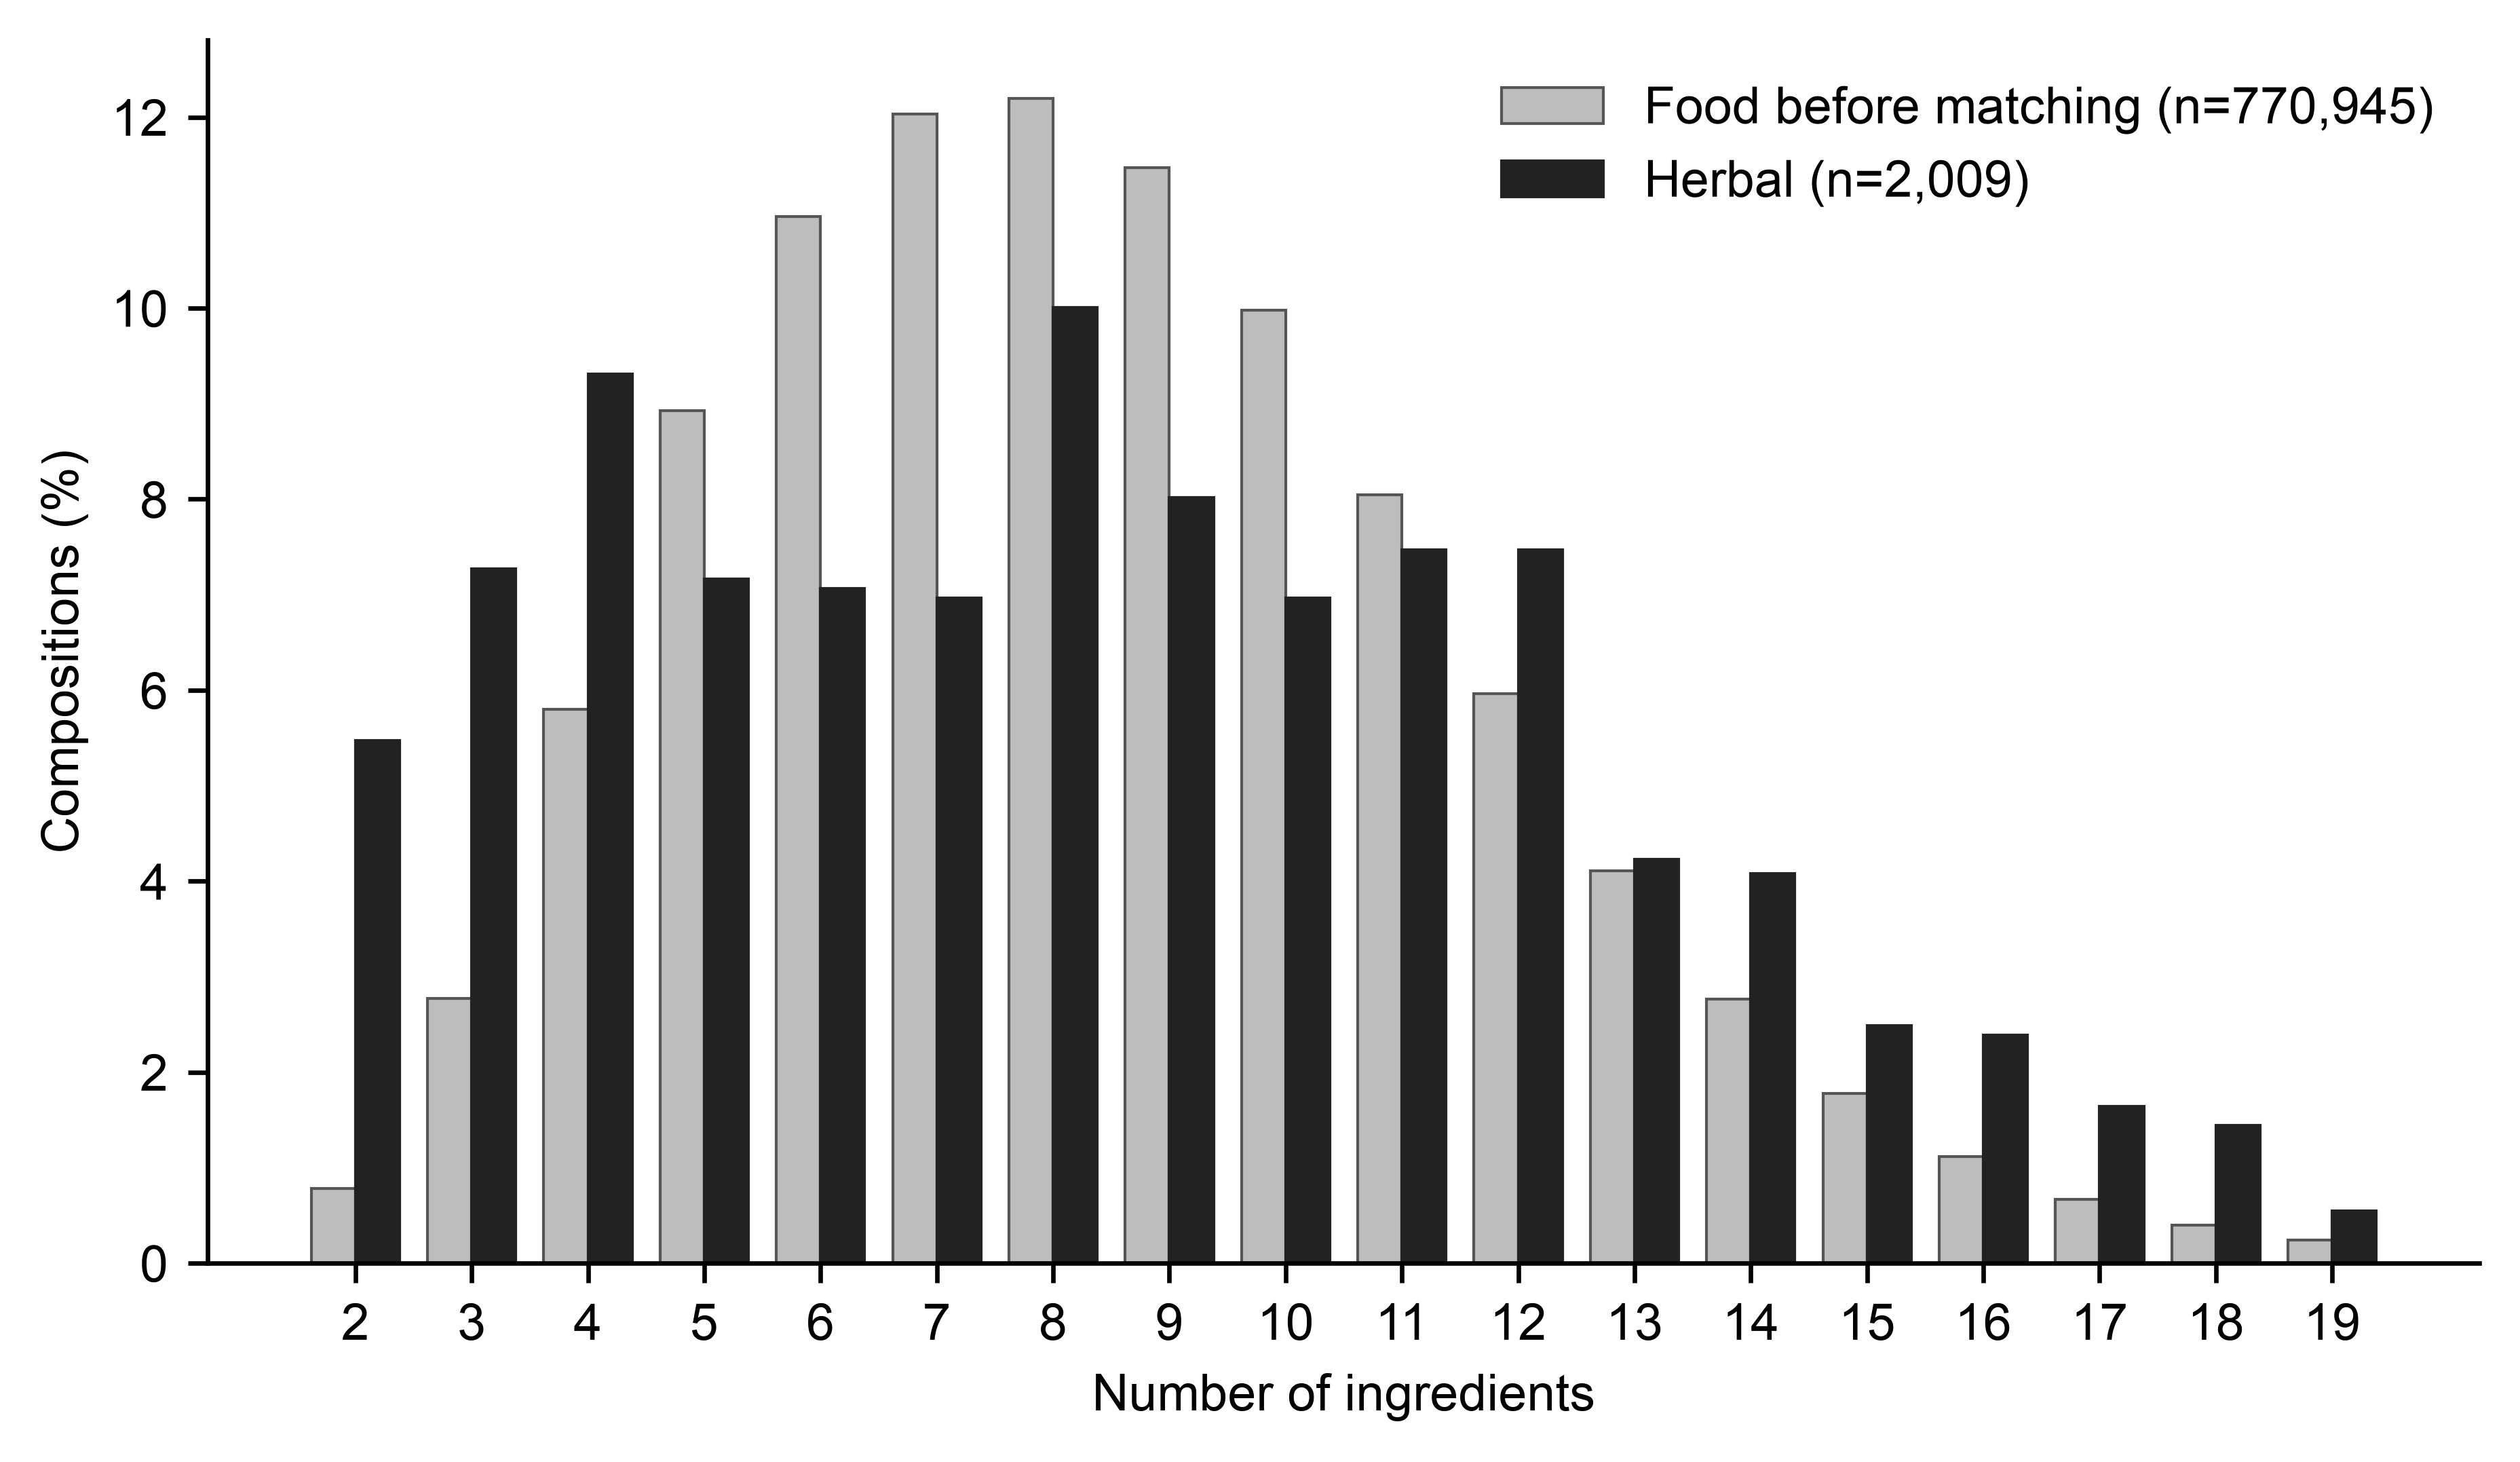

Saved: figures/Figure1_dataset_matching.png and .svg
Audit tables: work/dataset_flow.csv, work/input_manifest.json, work/food/, work/herbal/


In [8]:
assert not (fresh / "figures").exists(), "Rerun from step 2 for a fresh reproduction."
pipeline.make_figure1(checked_counts["herbal"], checked_counts["food"])
for folder in ["work", "figures"]:
    shutil.copytree(fresh / folder, repo / folder, dirs_exist_ok=True)
print("Newly generated figure:")
display(Image(filename=str(fresh / "figures/Figure1_dataset_matching.png")))
print("Saved: figures/Figure1_dataset_matching.png and .svg")
print("Audit tables: work/dataset_flow.csv, work/input_manifest.json, work/food/, work/herbal/")


## 9. 세 추천 방법: 같은 평가 조성의 후보와 점수

고유 조성 ID 정렬 → 고정 seed(20260812)로 섞기 → 재료 수 합이 비슷하도록 다섯 fold에 배정합니다. 육미지황탕 조성이 속한 fold를 평가자료로 남기고, 나머지 네 fold에서만 원자료 반복 가중치를 반영한 출현·공출현 횟수를 계산합니다. 아래 자료 수는 실제 분할에서 산출하며 하드코딩하지 않습니다.

목단피·산수유를 입력으로 주고 복령·산약·숙지황·택사를 숨깁니다. 후보는 학습자료에 등장한 약재 중 입력에 없는 약재입니다. 점수 내림차순, 동점이면 약재명 순으로 정확히 10개를 고릅니다.

- **Popularity:** 학습자료에서 후보의 가중 출현 횟수.
- **Mean conditional probability:** 각 입력 약재가 등장한 기록 중 후보도 등장한 비율을 구해 평균한 값.
- **Mean pairwise Jaccard:** 각 입력–후보 쌍에서 하나라도 등장한 기록 중 둘 다 등장한 비율을 구해 평균한 값.

두 비율 점수는 0–1로 표시합니다. Popularity는 횟수이므로 방법 사이의 점수 크기를 직접 비교하지 않습니다. 표의 ‘숨긴 약재’는 원래 조성에서 숨긴 약재에 해당하는지를 나타냅니다. 이 한 사례의 순위는 전체 성능 비교가 아닙니다.


In [9]:
from html import escape
from IPython.display import HTML

example_meta, recommendation_rows, pair_support = pipeline.recommendation_example(
    fresh / "work/herbal/unique_compositions.csv", fresh / "work/recommendation_example"
)

def show_table(headers, rows):
    html = "<table><thead><tr>" + "".join("<th>" + escape(str(h)) + "</th>" for h in headers) + "</tr></thead><tbody>"
    html += "".join("<tr>" + "".join("<td>" + escape(str(v)) + "</td>" for v in row) + "</tr>" for row in rows)
    display(HTML(html + "</tbody></table>"))

show_table(["학습 고유 조성", "평가 고유 조성", "학습 원자료 가중 합", "예시의 평가 fold"], [[
    example_meta["training_unique_compositions"], example_meta["test_unique_compositions"],
    example_meta["training_source_weight_sum"], example_meta["example_test_fold"]
]])
for method, label in [("popularity", "Popularity"), ("mean_conditional", "Mean conditional probability"), ("mean_jaccard", "Mean pairwise Jaccard")]:
    print(label)
    rows = [r for r in recommendation_rows if r["method"] == method]
    assert len(rows) == 10 and len({r["candidate"] for r in rows}) == 10
    assert not set(example_meta["input"]) & {r["candidate"] for r in rows}
    show_table(["순위", "추천 후보", "점수", "숨긴 약재"], [[r["rank"], r["candidate"],
        str(r["score"]) if method == "popularity" else f'{r["score"]:.6f}',
        "예" if r["withheld_herb"] else "아니오"] for r in rows])
print("실제 계산 근거: 감초·숙지황·산약")
show_table(["입력", "후보", "입력 등장", "후보 등장", "둘 다 등장", "하나 이상 등장", "조건부 비율", "Jaccard"], [
    [r["input"], r["candidate"], r["input_weighted_count"], r["candidate_weighted_count"],
     r["both_weighted_count"], r["either_weighted_count"], f'{r["conditional"]:.6f}', f'{r["jaccard"]:.6f}']
    for r in pair_support if r["candidate"] in {"감초", "숙지황", "산약"}
])
shutil.copytree(fresh / "work/recommendation_example", repo / "work/recommendation_example", dirs_exist_ok=True)
print("Saved: work/recommendation_example/top10.csv, all_candidate_scores.csv, pair_support.csv, fold_assignments.csv, metadata.json")


{
  "fold_seed": 20260812,
  "number_of_folds": 5,
  "fold_sizes": [
    402,
    402,
    402,
    402,
    401
  ],
  "example_test_fold": 5,
  "training_unique_compositions": 1608,
  "test_unique_compositions": 401,
  "training_source_weight_sum": 2391,
  "example_composition_id": "5b5d004698b9c64f",
  "excluded_example_source_weight": 19,
  "input": [
    "목단피",
    "산수유"
  ],
  "withheld": [
    "복령",
    "산약",
    "숙지황",
    "택사"
  ],
  "herbal_source_sha256": "87ef572d72146604f6006798c5156cc91974091c949705f52397aeedc8a3a3d6",
  "fold_policy": "Sort IDs, seeded shuffle, stable descending length sort, then assign to lowest total length; break ties by fold size and index",
  "scores": {
    "popularity": "weighted occurrence count",
    "mean_conditional": "mean conditional proportion (0–1)",
    "mean_jaccard": "mean pairwise Jaccard similarity (0–1)"
  },
  "ranking": "descending score, then ascending ingredient name (Unicode)",
  "scope": "one illustrative herbal test case, not 

학습 고유 조성,평가 고유 조성,학습 원자료 가중 합,예시의 평가 fold
1608,401,2391,5


Popularity


순위,추천 후보,점수,숨긴 약재
1,감초,1288,아니오
2,진피,634,아니오
3,인삼,629,아니오
4,생강,592,아니오
5,반하,558,아니오
6,백출,486,아니오
7,복령,454,예
8,당귀,437,아니오
9,작약,367,아니오
10,황금,339,아니오


Mean conditional probability


...

Mean pairwise Jaccard


순위,추천 후보,점수,숨긴 약재
1,산약,0.409591,예
2,택사,0.339335,예
3,숙지황,0.291840,예
4,복령,0.165786,예
5,부자,0.164442,아니오
6,육계,0.139789,아니오
7,오미자,0.124501,아니오
8,구기자,0.112385,아니오
9,황백,0.100171,아니오
10,우슬,0.092012,아니오


실제 계산 근거: 감초·숙지황·산약


입력,후보,입력 등장,후보 등장,둘 다 등장,하나 이상 등장,조건부 비율,Jaccard
목단피,감초,126,1288,44,1370,0.349206,0.032117
목단피,산약,126,172,73,225,0.579365,0.324444
목단피,숙지황,126,273,79,320,0.626984,0.246875
산수유,감초,112,1288,24,1376,0.214286,0.017442
산수유,산약,112,172,94,190,0.839286,0.494737
산수유,숙지황,112,273,97,288,0.866071,0.336806


Saved: work/recommendation_example/top10.csv, all_candidate_scores.csv, pair_support.csv, fold_assignments.csv, metadata.json


## 10. 전체 추천 성능: 한약과 음식 표본 100개

각 자료를 동일한 규칙과 seed로 다섯 fold에 나누고, 네 fold로 학습하여 나머지 fold를 평가합니다. 입력으로 2개, 3개, 전체의 50%, 75%, 또는 한 개를 제외한 모든 재료(N−1)를 제공합니다. 2개/3개 입력 후 숨길 재료가 없는 조성은 해당 조건에서 제외합니다. 비율은 반올림(0.5는 올림)하고 최소 1개, 최대 N−1개로 제한합니다.

각 조성·조건에서 가능한 입력 조합이 5개 이하면 모두 사용하고, 더 많으면 고정 seed로 서로 다른 5개를 추출합니다. 세 방법은 같은 입력을 사용합니다. 학습에서 보지 못한 숨긴 재료도 정답의 분모에 남겨 오답으로 셉니다. 이미 입력한 재료를 제외하고 정확히 10개를 추천하며, 동점은 재료명 Unicode 순서로 정합니다.

평가값은 숨긴 재료 중 Top 10에 포함된 비율(Recall@10)입니다. N−1에서는 숨긴 한 재료를 찾았는지(Hit@10)와 같습니다. 먼저 각 조성의 입력 조합 점수를 평균하고, 평가 가능한 고유 조성에 동일한 비중을 주어 전체 fold를 합칩니다. 원자료 기록 수 가중치는 학습에만 사용합니다.

음식은 표본 100개의 성능 평균과 표준편차, 경험적 2.5–97.5 백분위 범위를 표시합니다. 이 범위는 표본 간 변동이며 신뢰구간이 아닙니다. 아래 평가는 앞에서 새로 생성한 자료만 사용합니다.

**Figure 2:** 한약과 음식을 별도 그래프로 표시합니다. Figure 1과 같은 글꼴·흑백 막대 스타일을 사용하며, 각 그래프에서 세 방법을 비교합니다. 음식 오차막대는 표본 간 백분위 범위입니다. 상세 수치는 CSV로 보존합니다.


입력 조건,평가 조성 수,제외 조성 수
2,1899,110
3,1753,256
50%,2009,0
75%,2009,0
N-1,2009,0


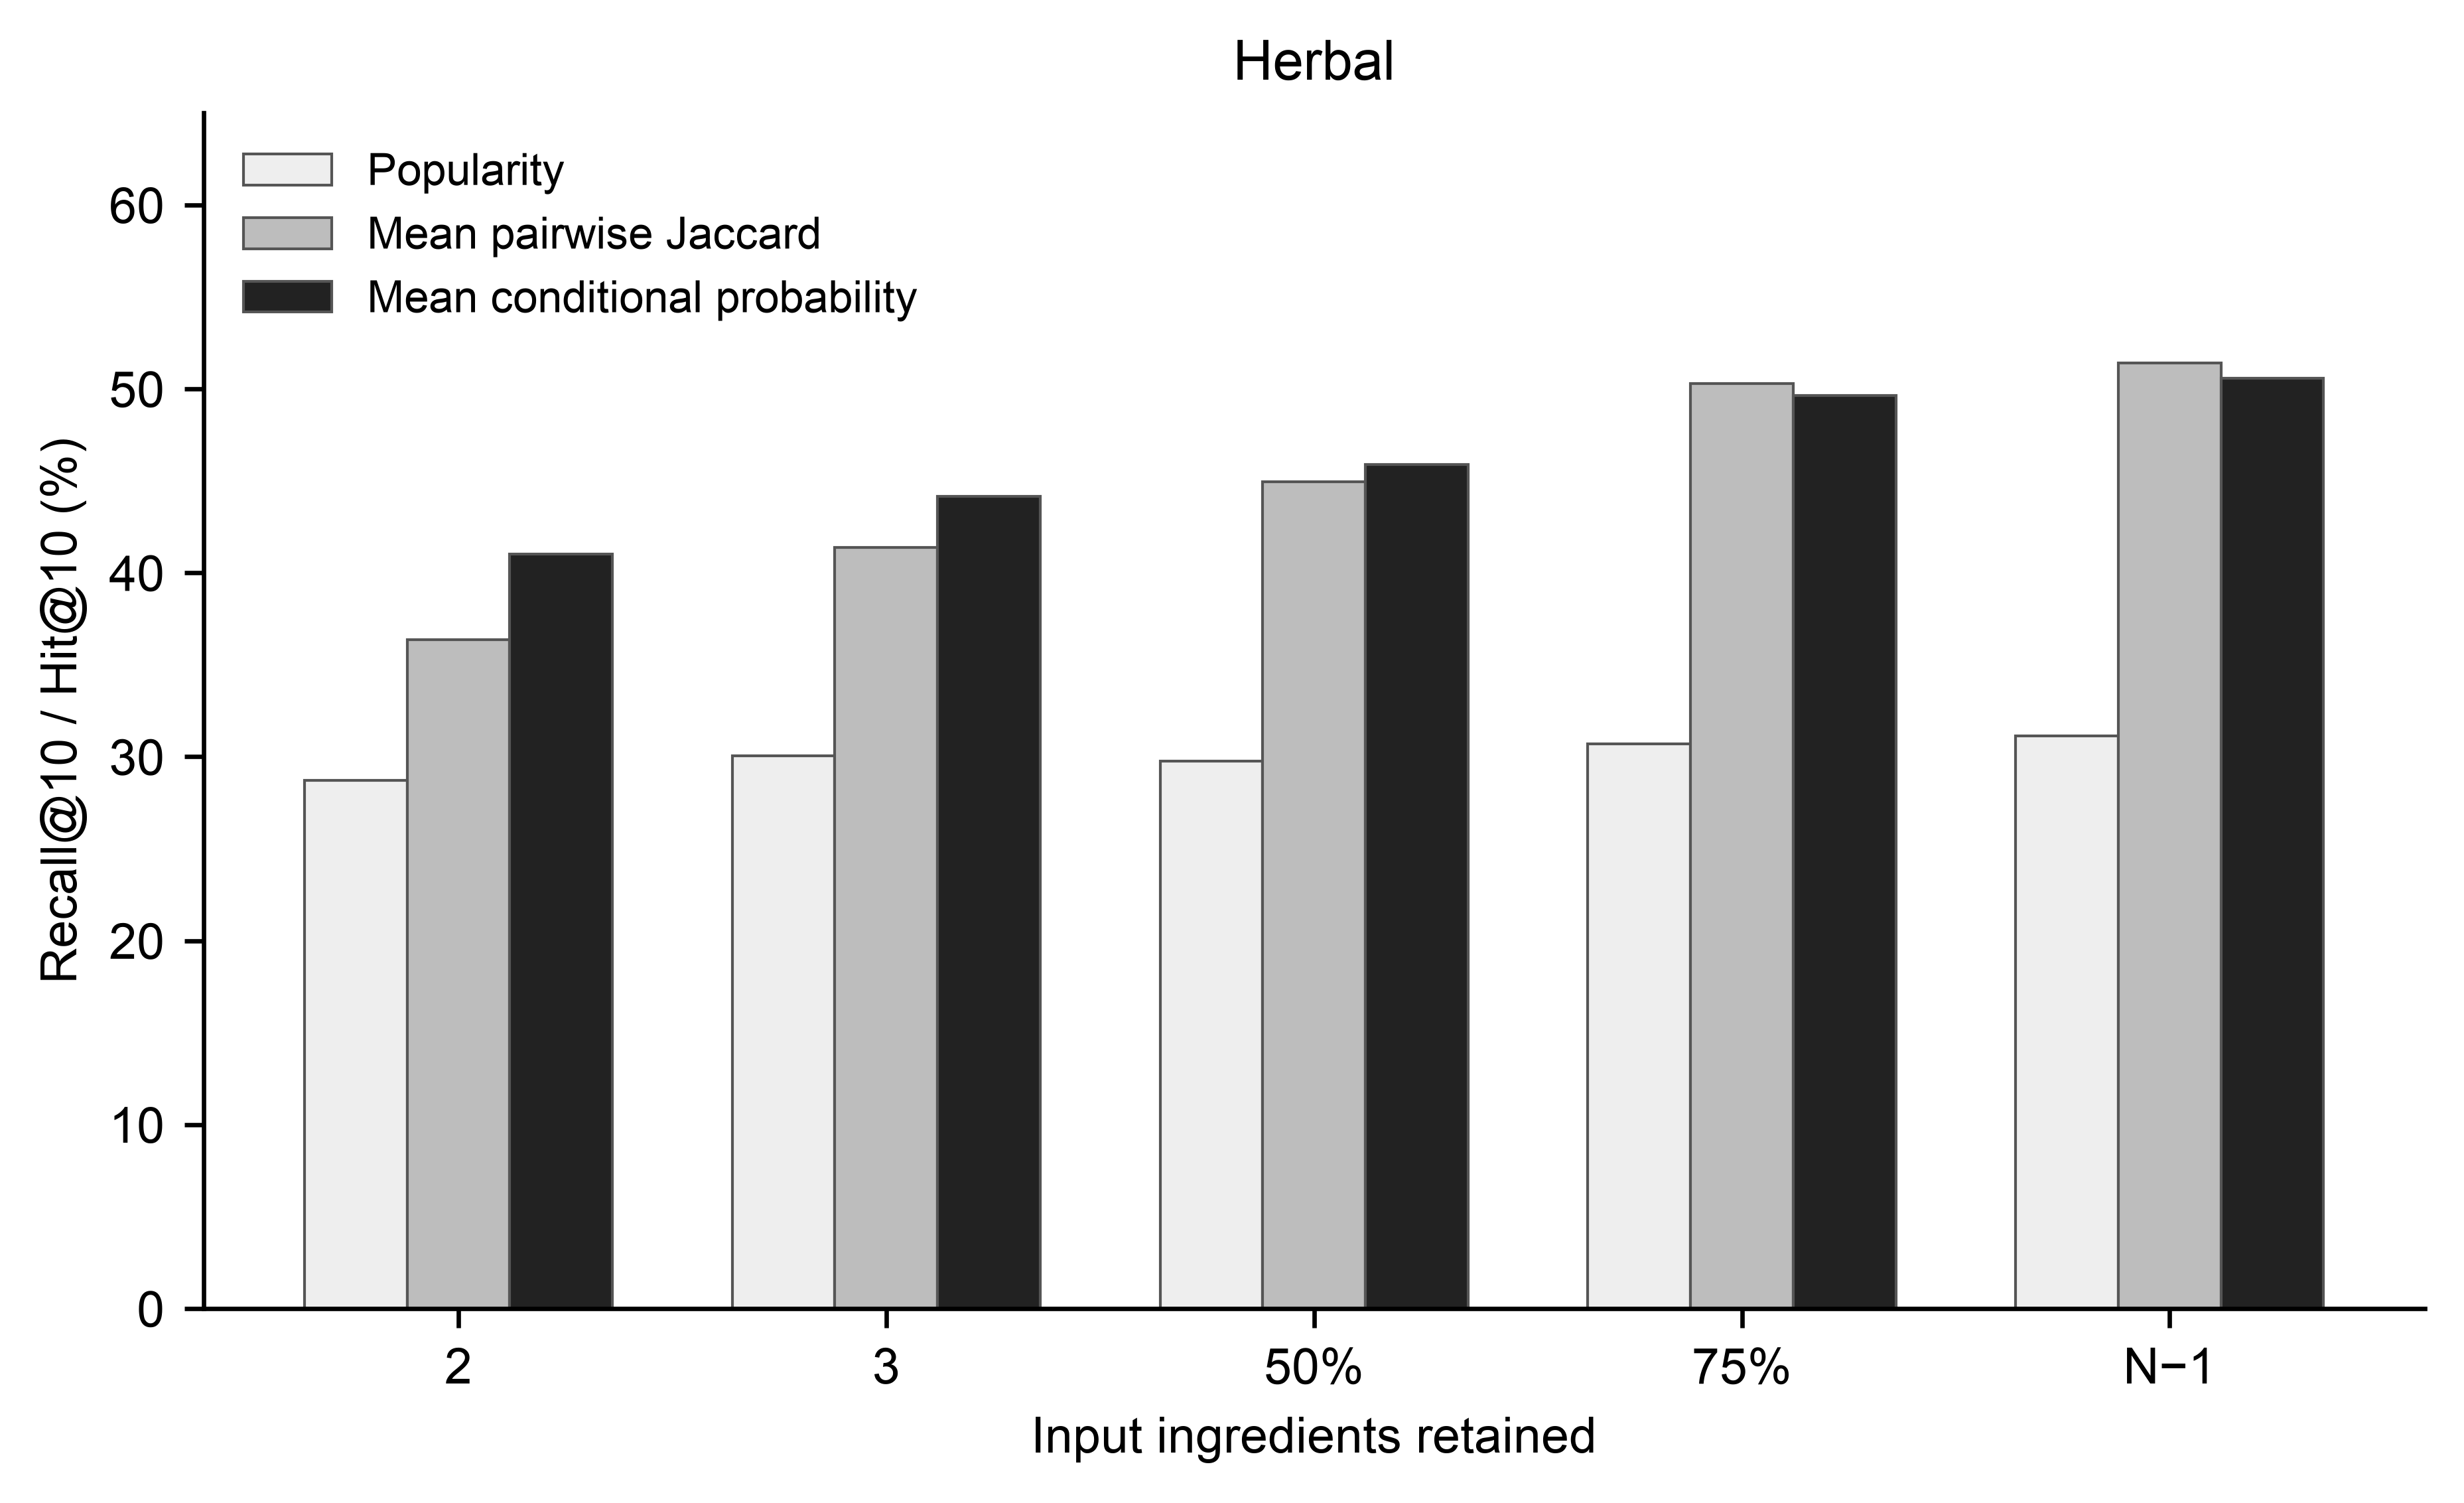

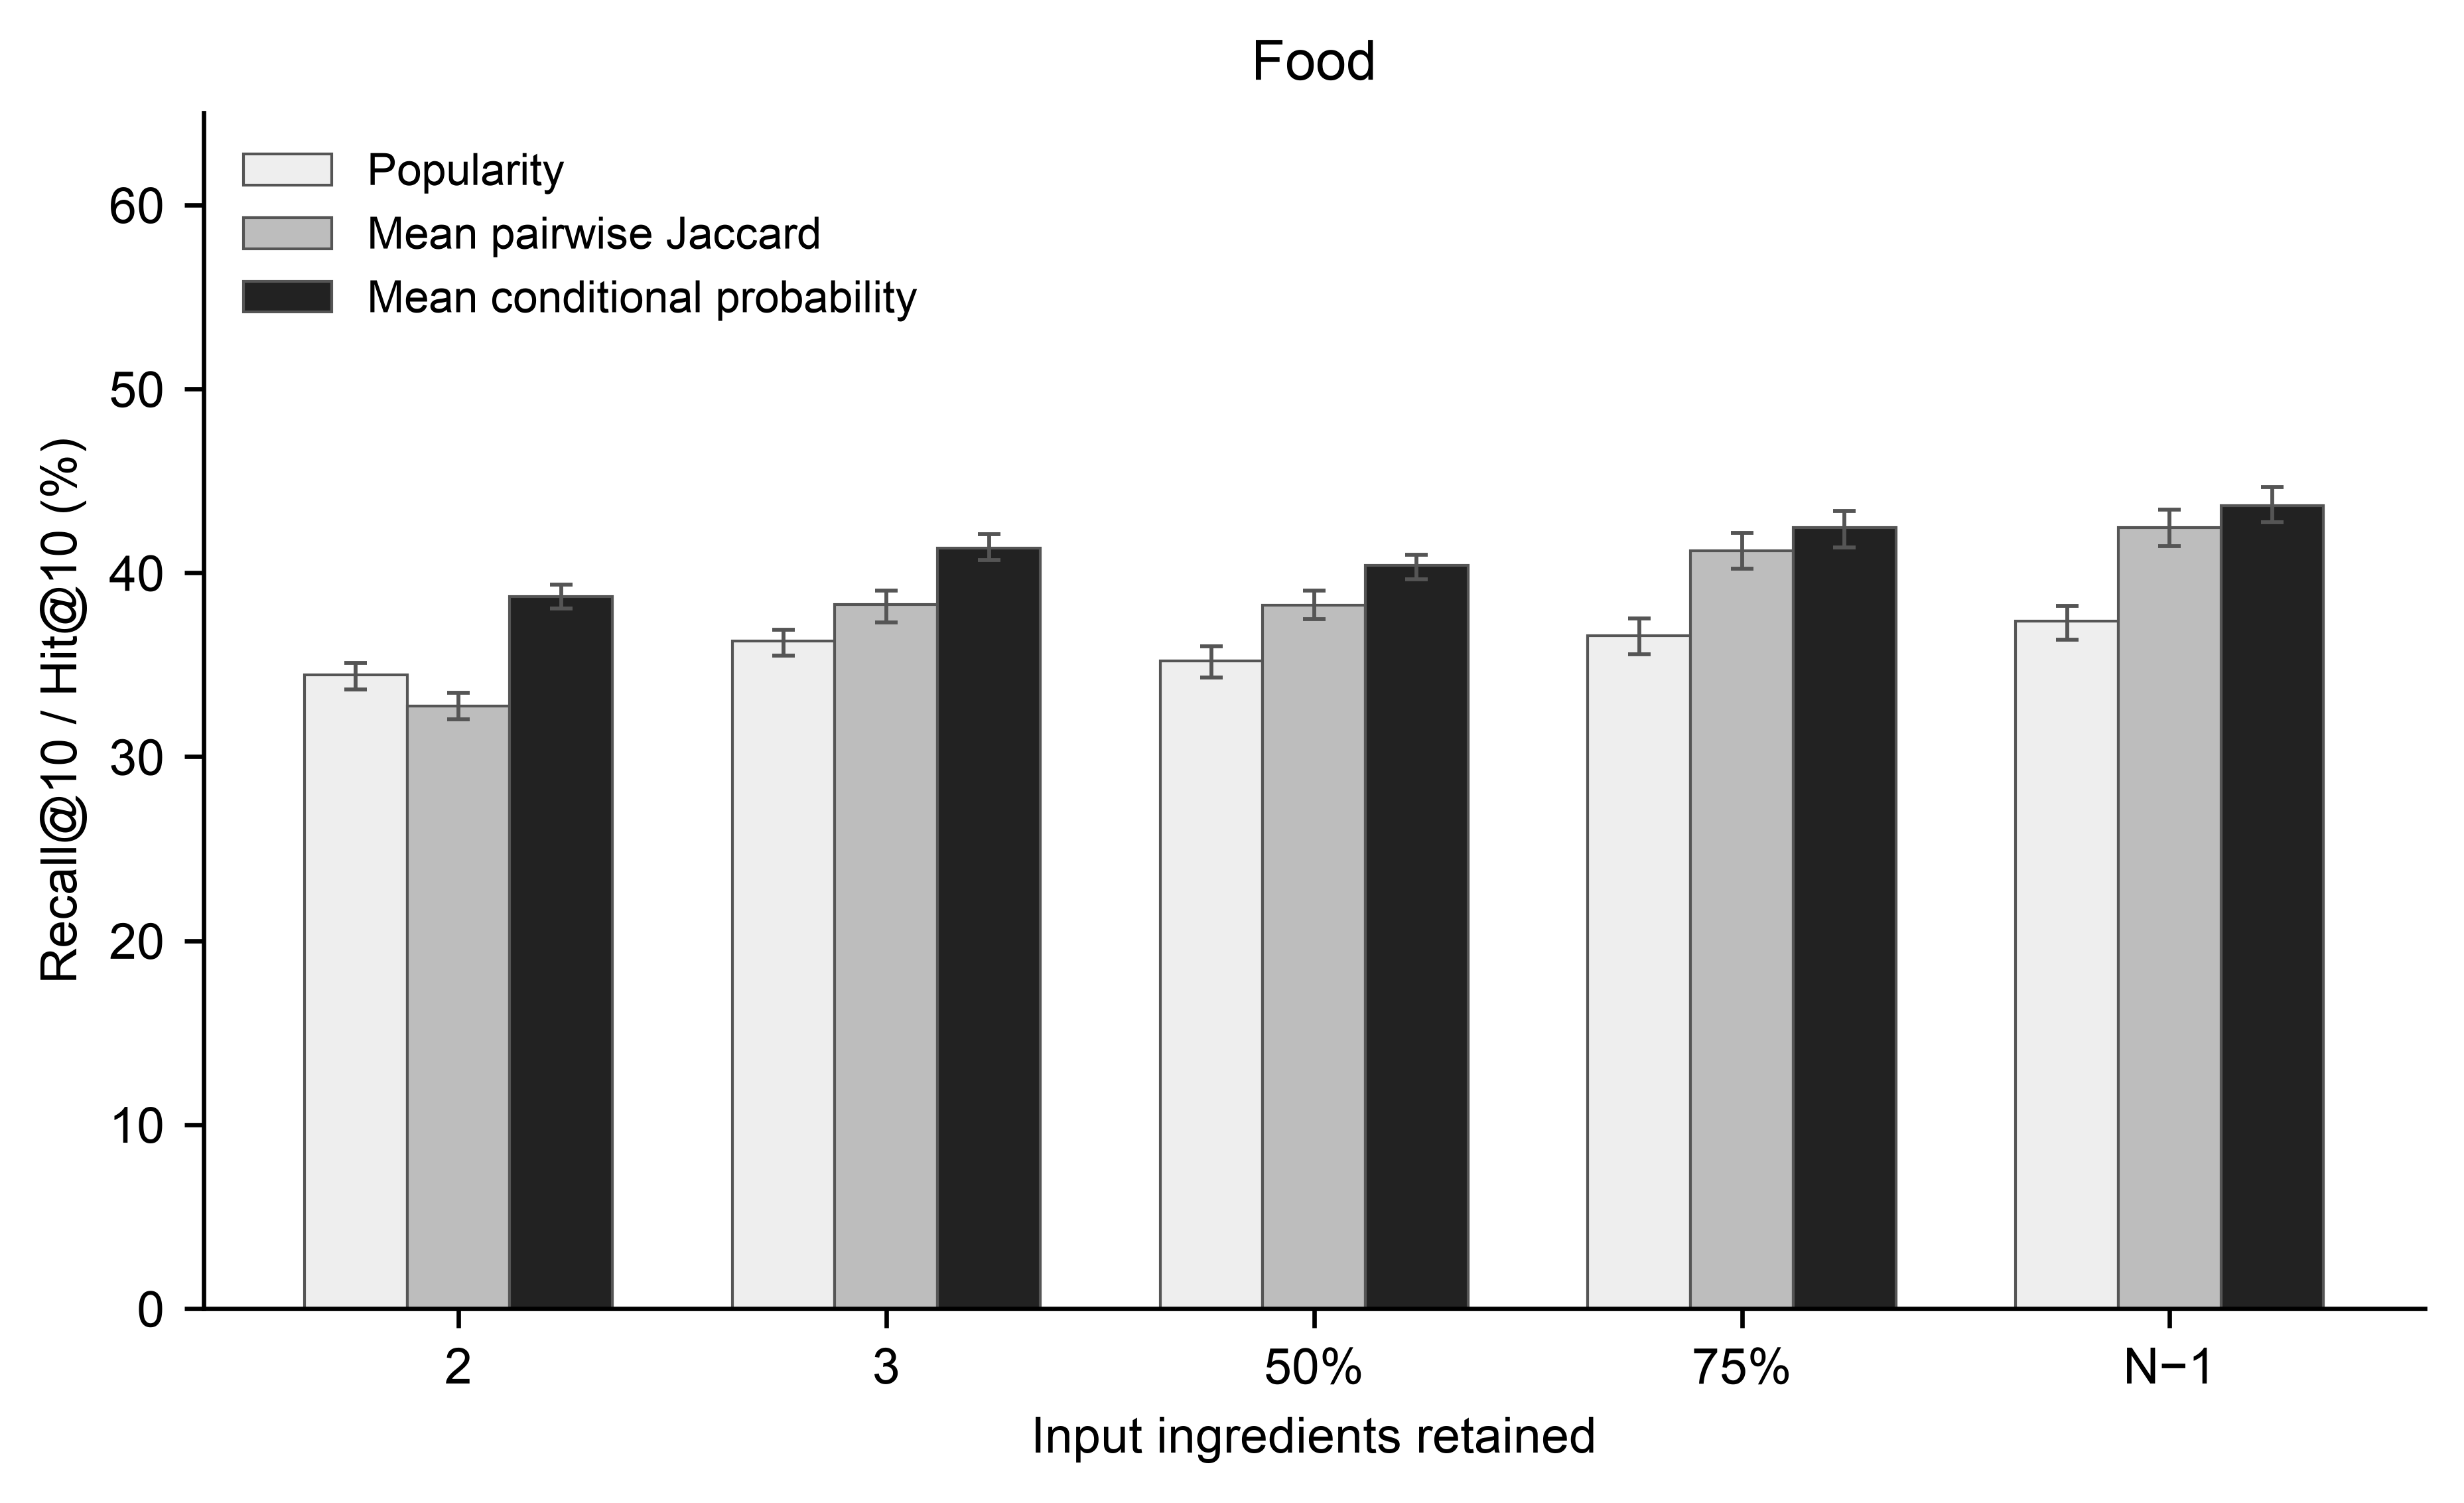

Fig. 2. Ingredient recommendation performance in herbal formulas and matched food samples. Separate plots show herbal performance and mean performance across 100 matched food samples. Bars represent Popularity, Mean conditional probability, and Mean pairwise Jaccard. Food error bars show the empirical 2.5th–97.5th percentiles across samples, not confidence intervals. Input conditions retain 2 or 3 ingredients, 50% or 75% of ingredients, or all but one ingredient (N−1). Performance is Recall@10, equivalent to Hit@10 for N−1. Scores are averaged within each composition and then equally across eligible compositions. Each cohort includes 1,899 eligible compositions for the 2-ingredient condition, 1,753 for the 3-ingredient condition, and 2,009 for each remaining condition.

Saved: work/evaluation/summary.csv, sample_results.csv, fold_results.csv, metadata.json
각 조성의 점수와 fold 배정은 work/evaluation/cohorts/에 저장됩니다.


In [10]:
subprocess.run([sys.executable, "-u", str(fresh / "run.py"), "--evaluate-only", "--workers", "2"], check=True)
evaluation_dir = fresh / "work/evaluation"
summary = pipeline.read_rows(evaluation_dir / "summary.csv")
metadata = json.loads((evaluation_dir / "metadata.json").read_text())
assert metadata["status"] == "complete" and metadata["evaluated_cohorts"] == 101
labels = {"popularity": "Popularity", "mean_conditional": "Mean conditional probability", "mean_jaccard": "Mean pairwise Jaccard"}
show_table(["입력 조건", "평가 조성 수", "제외 조성 수"], [
    [r["condition"], r["eligible_unique_per_cohort"], r["excluded_unique_per_cohort"]]
    for r in summary if r["method"] == "popularity"
])
pipeline.make_evaluation_figure(summary, fresh / "figures")
for domain in ("herbal", "food"):
    display(Image(filename=str(fresh / f"figures/Figure2_{domain}_performance.png")))
print((fresh / "figures/Figure2_caption.txt").read_text())
shutil.copytree(fresh / "figures", repo / "figures", dirs_exist_ok=True)
shutil.copytree(evaluation_dir, repo / "work/evaluation", dirs_exist_ok=True)
print("Saved: work/evaluation/summary.csv, sample_results.csv, fold_results.csv, metadata.json")
print("각 조성의 점수와 fold 배정은 work/evaluation/cohorts/에 저장됩니다.")


<details><summary>MIT License</summary>

MIT License

Copyright (c) 2026 inseong101

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

</details>